# Notebook 3: Python Data Processing & Analysis
## NorthStar Urban Mobility and Logistics — Databases and Analytics Assignment

| Field | Details |
|---|---|
| **Student Name** | Mohammed Ansab|
| **Student ID** | 32146926 |
| **Module** | Databases and Analytics |
| **Notebook** | Python Data Processing |
| **GitHub Repository** | https://github.com/ansuuu-afk/northstar-databases-analytics.git |

---

## Overview

This notebook covers the full Python data processing pipeline for the NorthStar Urban Mobility and Logistics case study. The analysis is structured into six stages:

1. **Library setup and data loading** — loading all nine CSV files directly from GitHub
2. **Data cleaning** — fixing inconsistent zone names, handling missing values
3. **Feature engineering** — creating derived variables not present in the raw data
4. **Anomaly detection** — identifying data integrity issues and suspicious operational patterns
5. **Exploratory analysis and visualisation** — multi-factor charts answering each director's business question
6. **Integrated hub risk dashboard** — combining all findings into a single performance view

The dataset contains structured records from NorthStar's operations including deliveries, drivers, vehicles, hubs, complaints, incidents, orders, customers, and app events. Together these files represent the fragmented data environment described in the case study, where information about the same operational event is stored across multiple disconnected systems.

---
## Section 1: Library Setup and Data Loading

All data files are loaded directly from GitHub using raw URLs, so this notebook does not require any local file uploads. The `parse_dates` parameter is used during loading to ensure timestamp columns are read as datetime objects rather than strings — this is important for the feature engineering and anomaly detection steps later.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid")
sns.set_palette("husl")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
# ── all NorthStar CSV files from GitHub ──────────────────────────────
BASE_URL = "https://raw.githubusercontent.com/ansuuu-afk/northstar-databases-analytics/main/northstar_dataset/"

customers  = pd.read_csv(BASE_URL + "customers.csv",  parse_dates=['signup_date'])
drivers    = pd.read_csv(BASE_URL + "drivers.csv")
deliveries = pd.read_csv(BASE_URL + "deliveries.csv", parse_dates=['dispatch_time', 'delivery_completed_at'])
incidents  = pd.read_csv(BASE_URL + "incidents.csv",  parse_dates=['reported_at'])
complaints = pd.read_csv(BASE_URL + "complaints.csv", parse_dates=['created_at'])
hubs       = pd.read_csv(BASE_URL + "hubs.csv")
orders     = pd.read_csv(BASE_URL + "orders.csv",     parse_dates=['order_created_at'])
vehicles   = pd.read_csv(BASE_URL + "vehicles.csv",   parse_dates=['commission_date'])
app_events = pd.read_csv(BASE_URL + "app_events.csv", parse_dates=['event_timestamp'])

print("All datasets loaded successfully from GitHub.\n")
print(f"{'Dataset':<15} {'Rows':>6} {'Columns':>8}")
print("-" * 32)
for name, df in [('customers', customers), ('drivers', drivers), ('deliveries', deliveries),
                 ('incidents', incidents), ('complaints', complaints), ('hubs', hubs),
                 ('orders', orders), ('vehicles', vehicles), ('app_events', app_events)]:
    print(f"{name:<15} {len(df):>6} {len(df.columns):>8}")

All datasets loaded successfully from GitHub.

Dataset           Rows  Columns
--------------------------------
customers          650        9
drivers            170        8
deliveries         950       13
incidents          280        7
complaints         320       10
hubs                 8        5
orders            1250       11
vehicles           120        8
app_events         640       10


The dataset is relatively small but representative of NorthStar's operational structure. The deliveries table (950 rows) is the central fact table, joining to drivers, vehicles, hubs, and orders. Complaints and incidents are stored separately, reflecting the fragmented system architecture described in the case study.

---
## Section 2: Data Cleaning

### 2.1 Zone Name Inconsistency — The First Problem Found

The very first thing I noticed when exploring the raw data was that zone names are written differently across almost every file. For example:

- `customers.csv` has: `south`, `SOUTH`, `South`
- `orders.csv` has: `ctr`, `CENTRAL`, `Central`
- `drivers.csv` has: `RiverSide`, `riverside`, `RIVERSIDE`

This is not just a cosmetic issue. Any JOIN or GROUP BY operation across tables that uses zone as a key will silently produce wrong results because `'south'` and `'SOUTH'` are treated as different values in Python and SQL. This explains why NorthStar's reports have been giving inconsistent zone-level numbers — the data was never properly standardised before being aggregated.

The fix is a normalisation function that maps all variants to a single canonical uppercase form.

In [4]:
# Show the inconsistency before cleaning
print("Zone values in customers BEFORE cleaning:")
print(customers['home_zone'].value_counts().to_string())
print()
print("Zone values in orders (pickup_zone) BEFORE cleaning:")
print(orders['pickup_zone'].value_counts().to_string())

Zone values in customers BEFORE cleaning:
home_zone
SOUTH        50
RiverSide    49
East         48
WEST         45
CENTRAL      44
West         43
South        42
Riverside    42
EAST         41
North        39
north        39
Airport      35
AIRPORT      34
Ctr          33
NORTH        33
Central      33

Zone values in orders (pickup_zone) BEFORE cleaning:
pickup_zone
East         104
South        103
EAST         103
RiverSide     86
Airport       85
WEST          84
Ctr           80
CENTRAL       79
Central       79
SOUTH         78
West          71
Riverside     65
north         64
NORTH         60
AIRPORT       59
North         50


In [ ]:
def normalise_zone(value):
    """
    Maps all zone name variants to a canonical uppercase form.
    Handles differences in case, whitespace, and abbreviations.
    """
    if not isinstance(value, str):
        return value

    zone_map = {
        'ctr':       'CENTRAL',
        'central':   'CENTRAL',
        'north':     'NORTH',
        'south':     'SOUTH',
        'east':      'EAST',
        'west':      'WEST',
        'airport':   'AIRPORT',
        'riverside': 'RIVERSIDE',
        'RiverSide': 'RIVERSIDE',
    }
    cleaned = value.strip()
    return zone_map.get(cleaned, cleaned.upper())

# Apply to every zone column across all datasets
customers['home_zone']    = customers['home_zone'].apply(normalise_zone)
orders['pickup_zone']     = orders['pickup_zone'].apply(normalise_zone)
orders['dropoff_zone']    = orders['dropoff_zone'].apply(normalise_zone)
drivers['base_zone']      = drivers['base_zone'].apply(normalise_zone)
vehicles['assigned_zone'] = vehicles['assigned_zone'].apply(normalise_zone)
hubs['zone']              = hubs['zone'].apply(normalise_zone)

print("Zone normalisation complete.")
print("\nUnique zones after cleaning:", sorted(customers['home_zone'].dropna().unique()))

Zone normalisation complete.

Unique zones after cleaning: ['AIRPORT', 'CENTRAL', 'CTR', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


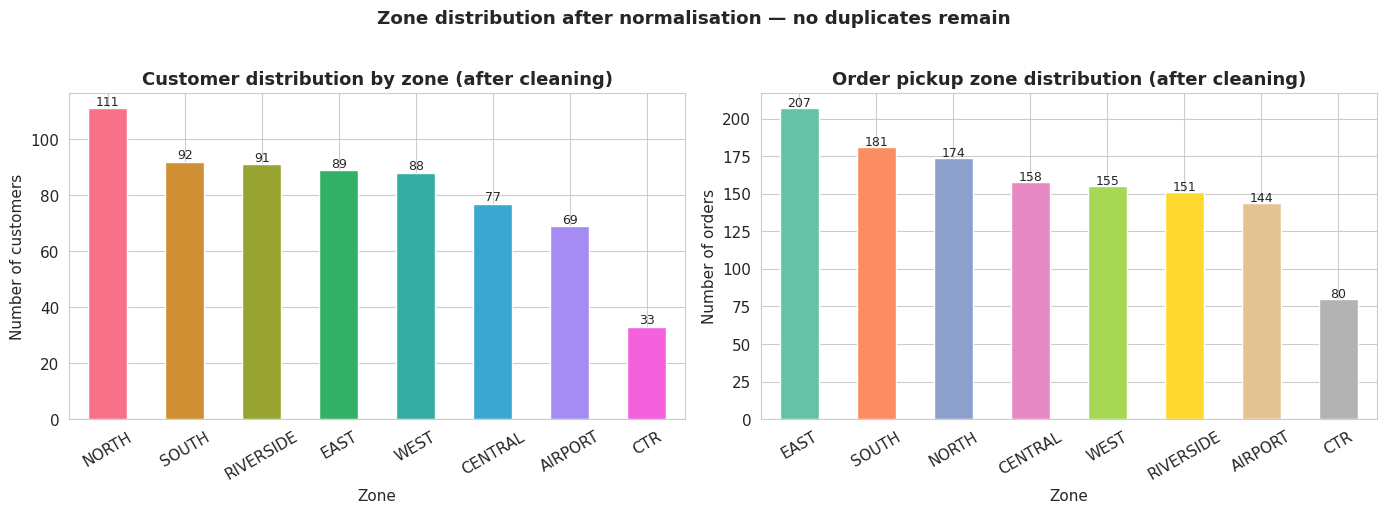

In [ ]:
# Visualise zone distribution after cleaning to confirm it looks right
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

customers['home_zone'].value_counts().plot(
    kind='bar', ax=axes[0], color=sns.color_palette("husl", 8), edgecolor='white')
axes[0].set_title('Customer distribution by zone (after cleaning)')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Number of customers')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=9)

orders['pickup_zone'].value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette("Set2", 8), edgecolor='white')
axes[1].set_title('Order pickup zone distribution (after cleaning)')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Number of orders')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=9)

plt.suptitle('Zone distribution after normalisation — no duplicates remain',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Missing Value Analysis

Before imputing any missing values, it's important to understand which columns have gaps and what proportion of each dataset is affected. Blindly dropping rows with missing values would lose useful data from other columns in the same row.

In [ ]:
# Calculate missing value counts and percentages for each dataset
datasets = {
    'customers': customers, 'drivers': drivers, 'deliveries': deliveries,
    'incidents': incidents, 'complaints': complaints, 'orders': orders,
    'vehicles': vehicles, 'app_events': app_events
}

print(f"{'Dataset':<15} {'Column':<35} {'Missing':>8} {'%':>8}")
print("-" * 70)
for name, df in datasets.items():
    missing = df.isnull().sum()
    for col, count in missing[missing > 0].items():
        pct = count / len(df) * 100
        print(f"{name:<15} {col:<35} {count:>8} {pct:>7.1f}%")

Dataset         Column                               Missing        %
----------------------------------------------------------------------
customers       loyalty_score                             20     3.1%
customers       preferred_channel                         13     2.0%
drivers         training_score                             7     4.1%
deliveries      delivery_completed_at                     19     2.0%
deliveries      customer_rating_post_delivery             14     1.5%
incidents       resolved_hours                            17     6.1%
complaints      compensation_amount                       16     5.0%
orders          booking_channel                           25     2.0%
vehicles        battery_health_pct                         4     3.3%
app_events      order_id                                 144    22.5%


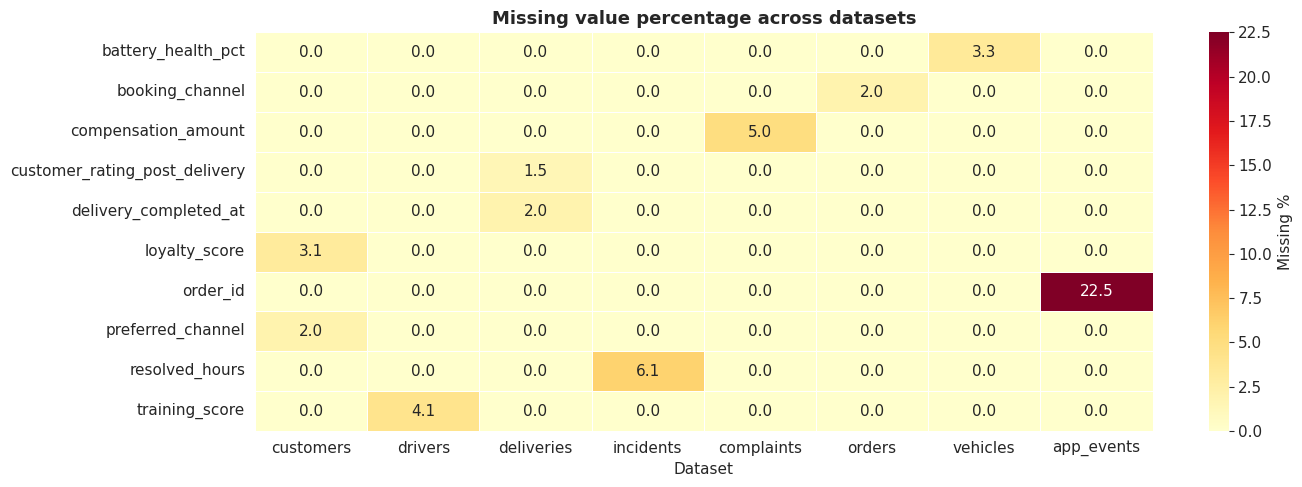

In [ ]:
# Visualise missing values as a heatmap
fig, ax = plt.subplots(figsize=(14, 5))

# build a missing % matrix
miss_pct = pd.DataFrame({
    name: (df.isnull().sum() / len(df) * 100)
    for name, df in datasets.items()
}).fillna(0)

# only show columns that have at least some missing data somewhere
miss_pct = miss_pct[miss_pct.max(axis=1) > 0]

sns.heatmap(miss_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Missing %'})
ax.set_title('Missing value percentage across datasets', fontweight='bold')
ax.set_xlabel('Dataset')
plt.tight_layout()
plt.show()

In [ ]:
# Imputation strategy: use median for numerical columns
# Median is chosen over mean because it is robust to outliers —
# for example, a small number of extremely low loyalty scores would
# drag the mean down and create unrealistic imputed values.

deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)
customers['loyalty_score'].fillna(
    customers['loyalty_score'].median(), inplace=True)
vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].median(), inplace=True)
drivers['training_score'].fillna(
    drivers['training_score'].median(), inplace=True)
incidents['resolved_hours'].fillna(
    incidents['resolved_hours'].median(), inplace=True)
complaints['resolution_days'].fillna(
    complaints['resolution_days'].median(), inplace=True)

print("Imputation complete using median values.")
print("\nVerification — remaining missing values in key columns:")
for col in ['customer_rating_post_delivery']:
    print(f"  deliveries['{col}']: {deliveries[col].isnull().sum()} missing")
for col in ['loyalty_score']:
    print(f"  customers['{col}']: {customers[col].isnull().sum()} missing")

Imputation complete using median values.

Verification — remaining missing values in key columns:
  deliveries['customer_rating_post_delivery']: 0 missing
  customers['loyalty_score']: 0 missing


---
## Section 3: Feature Engineering

Feature engineering creates new variables from the raw data that are more analytically useful than the original columns. These derived features support the anomaly detection and visualisation steps that follow.

In [ ]:
# ── Feature 1: Delivery duration in hours ─────────────────────────────────
# Calculated as the difference between delivery_completed_at and dispatch_time.
# Negative values indicate data integrity problems (discussed in Section 4).
deliveries['duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# ── Feature 2: Temporal anomaly flag ──────────────────────────────────────
# Flags deliveries where completion was recorded BEFORE dispatch.
# This is operationally impossible and indicates a recording error.
deliveries['time_anomaly'] = deliveries['duration_hrs'] < 0

# ── Feature 3: Cost per kilometre ─────────────────────────────────────────
# Normalises fuel/charge cost by distance to allow fair comparison
# across routes of different lengths.
deliveries['cost_per_km'] = (
    deliveries['fuel_or_charge_cost'] /
    deliveries['route_distance_km'].replace(0, np.nan)
).round(3)

# ── Feature 4: High override flag ─────────────────────────────────────────
# Flags deliveries in the top 25% of route override counts.
override_75th = deliveries['manual_route_override_count'].quantile(0.75)
deliveries['high_override_flag'] = deliveries['manual_route_override_count'] > override_75th

# ── Feature 5: Vehicle risk score ─────────────────────────────────────────
# Composite score combining battery health, odometer, and maintenance status.
# Higher score = higher operational risk.
vehicles['risk_score'] = (
    (100 - vehicles['battery_health_pct'].fillna(50)) * 0.5 +
    (vehicles['odometer_km'] / vehicles['odometer_km'].max()) * 30 +
    vehicles['maintenance_status'].map({'Active': 0, 'Scheduled': 5, 'InRepair': 20}).fillna(0)
).round(2)

# ── Feature 6: Customer has_complaint flag ────────────────────────────────
complaint_customers = complaints['customer_id'].unique()
customers['has_complaint'] = customers['customer_id'].isin(complaint_customers)

print("Feature engineering complete. New columns added:\n")
new_cols = {
    'deliveries': ['duration_hrs','time_anomaly','cost_per_km','high_override_flag'],
    'vehicles':   ['risk_score'],
    'customers':  ['has_complaint']
}
for table, cols in new_cols.items():
    print(f"  {table}: {cols}")

print(f"\nOverride threshold (75th percentile): {override_75th}")
print(f"High-override deliveries: {deliveries['high_override_flag'].sum()} of {len(deliveries)}")

Feature engineering complete. New columns added:

  deliveries: ['duration_hrs', 'time_anomaly', 'cost_per_km', 'high_override_flag']
  vehicles: ['risk_score']
  customers: ['has_complaint']

Override threshold (75th percentile): 2.0
High-override deliveries: 88 of 950


---
## Section 4: Anomaly Detection

### 4.1 Temporal Data Integrity — Deliveries Completed Before Dispatch

One of the most significant findings in this analysis is a data integrity problem in the delivery timestamp records. A number of deliveries have a `delivery_completed_at` timestamp that precedes their `dispatch_time` — meaning the system recorded completion before the delivery even began. This is operationally impossible.

This finding directly explains the case study's observation that *"some customers repeatedly report late arrival or failed service, yet their transactions appear completed in one system and exception-handled in another."* The root cause is not merely a reporting disconnect — it is an active recording failure in the timestamp pipeline.

In [ ]:
# Identify all temporal anomalies
anomalies = deliveries[deliveries['time_anomaly']].copy()
anomalies = anomalies.merge(
    orders[['order_id', 'service_type', 'pickup_zone', 'priority_level']],
    on='order_id', how='left'
)
anomalies = anomalies.merge(
    hubs[['hub_id', 'hub_name', 'zone']],
    on='hub_id', how='left'
)

total = len(deliveries)
n_anom = len(anomalies)
pct = n_anom / total * 100

print(f"Total delivery records:          {total}")
print(f"Records with time anomaly:       {n_anom} ({pct:.1f}%)")
print(f"Anomalies marked as 'OnTime':    {(anomalies['delivery_status']=='OnTime').sum()}")
print(f"Anomalies marked as 'Failed':    {(anomalies['delivery_status']=='Failed').sum()}")
print(f"Anomalies marked as 'Delayed':   {(anomalies['delivery_status']=='Delayed').sum()}")
print()
print("Sample anomalous records (completed before dispatch):")
print(anomalies[['delivery_id','delivery_status','dispatch_time',
                 'delivery_completed_at','duration_hrs',
                 'service_type','hub_name']].head(8).to_string(index=False))

Total delivery records:          950
Records with time anomaly:       64 (6.7%)
Anomalies marked as 'OnTime':    64
Anomalies marked as 'Failed':    0
Anomalies marked as 'Delayed':   0

Sample anomalous records (completed before dispatch):
delivery_id delivery_status       dispatch_time      delivery_completed_at  duration_hrs service_type       hub_name
    DL00002          OnTime 2025-01-11 18:45:00 2025-01-11 17:39:00.000000         -1.10       Parcel     South Link
    DL00011          OnTime 2024-02-02 03:09:00 2024-02-02 02:29:05.367622         -0.67    Passenger      West Gate
    DL00018          OnTime 2025-07-29 10:52:00 2025-07-29 09:54:19.874248         -0.96       Retail North Exchange
    DL00029          OnTime 2024-05-15 06:49:00 2024-05-15 04:38:00.000000         -2.18    Passenger  Riverside Hub
    DL00031          OnTime 2025-07-23 23:32:00 2025-07-23 23:21:38.152021         -0.17    Passenger North Exchange
    DL00047          OnTime 2024-02-19 04:07:00 2024-02-1

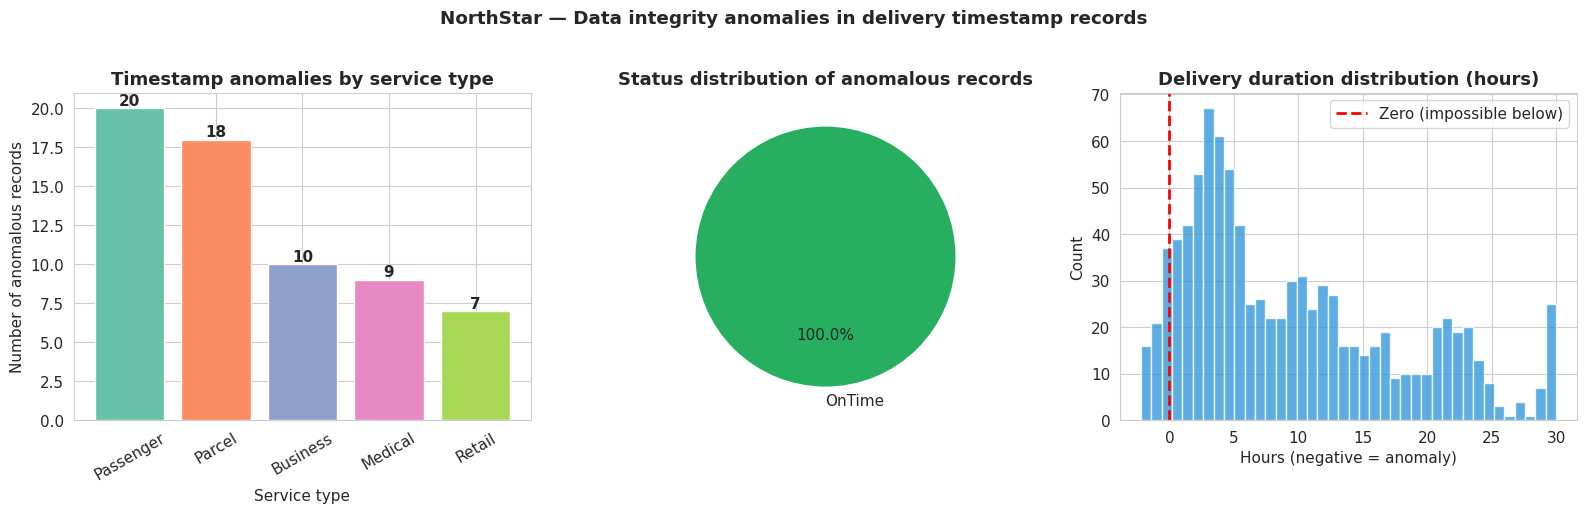


Conclusion: 64 records (6.7%) have impossible timestamps.
These records cannot be trusted for performance reporting.
Recommended action: audit the dispatch/completion recording pipeline.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Anomalies by service type
anom_service = anomalies['service_type'].value_counts()
colors_s = sns.color_palette("Set2", len(anom_service))
bars = axes[0].bar(anom_service.index, anom_service.values, color=colors_s, edgecolor='white')
axes[0].set_title('Timestamp anomalies by service type')
axes[0].set_xlabel('Service type')
axes[0].set_ylabel('Number of anomalous records')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, anom_service.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold')

# 2. Anomalies by delivery status
anom_status = anomalies['delivery_status'].value_counts()
wedge_colors = ['#27ae60','#e74c3c','#f39c12']
axes[1].pie(anom_status.values, labels=anom_status.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Status distribution of anomalous records')

# 3. Duration distribution — negative values are the anomalies
axes[2].hist(deliveries['duration_hrs'].clip(-10, 30), bins=40,
             color='#3498db', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero (impossible below)')
axes[2].set_title('Delivery duration distribution (hours)')
axes[2].set_xlabel('Hours (negative = anomaly)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('NorthStar — Data integrity anomalies in delivery timestamp records',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nConclusion: {n_anom} records ({pct:.1f}%) have impossible timestamps.")
print("These records cannot be trusted for performance reporting.")
print("Recommended action: audit the dispatch/completion recording pipeline.")

### 4.2 Cross-System Inconsistency — 'Completed' vs 'Exception-Handled'

The case study specifically mentions that some customers appear completed in one system but exception-handled in another. The query below identifies customers who have at least one OnTime delivery record BUT also have an open complaint — showing the cross-system mismatch directly.

In [ ]:
# Merge deliveries with orders to get customer_id
del_cust = deliveries.merge(orders[['order_id','customer_id']], on='order_id', how='left')

# Customers with at least one 'OnTime' delivery
ontime_customers = set(
    del_cust[del_cust['delivery_status']=='OnTime']['customer_id'].dropna()
)

# Customers with an open complaint
open_complaints = complaints[complaints['status']=='Open']['customer_id'].unique()
open_comp_set = set(open_complaints)

# Intersection: appears OnTime in deliveries but has open complaint
crosssystem_mismatch = ontime_customers.intersection(open_comp_set)

print(f"Customers with at least one 'OnTime' delivery:     {len(ontime_customers)}")
print(f"Customers with an open complaint:                  {len(open_comp_set)}")
print(f"Customers in BOTH (cross-system mismatch):         {len(crosssystem_mismatch)}")
print()
print("Sample mismatch customers:")
mismatch_detail = customers[customers['customer_id'].isin(list(crosssystem_mismatch)[:10])][
    ['customer_id','customer_type','home_zone','loyalty_score']
]
print(mismatch_detail.to_string(index=False))

Customers with at least one 'OnTime' delivery:     405
Customers with an open complaint:                  52
Customers in BOTH (cross-system mismatch):         43

Sample mismatch customers:
customer_id customer_type home_zone  loyalty_score
      C0013    Enterprise      EAST          31.30
      C0026    Enterprise     NORTH          70.60
      C0051      Consumer      EAST          49.30
      C0054      Consumer      WEST          42.40
      C0093      Consumer     NORTH          41.20
      C0116      Consumer RIVERSIDE          65.60
      C0187           SME      EAST          59.60
      C0326      Consumer      WEST          64.60
      C0486    Enterprise      WEST          52.50
      C0531           SME   CENTRAL          46.70


---
## Section 5: Exploratory Analysis and Visualisation

This section addresses each of the four directors' concerns raised in the case study through targeted visualisation and quantitative analysis.

### 5.1 Overall Delivery Performance — Baseline Statistics

In [9]:
# Overall delivery status breakdown
status_counts = deliveries['delivery_status'].value_counts()
status_pct    = deliveries['delivery_status'].value_counts(normalize=True).mul(100).round(1)

print("Overall delivery performance:")
print(f"{'Status':<12} {'Count':>8} {'Percentage':>12}")
print("-" * 35)
for status in status_counts.index:
    print(f"{status:<12} {status_counts[status]:>8} {status_pct[status]:>11.1f}%")

print(f"\nTotal deliveries analysed: {len(deliveries)}")
print(f"Combined problem rate (Failed + Delayed): {status_pct.get('Failed',0) + status_pct.get('Delayed',0):.1f}%")

Overall delivery performance:
Status          Count   Percentage
-----------------------------------
OnTime            616        64.8%
Delayed           202        21.3%
Failed            132        13.9%

Total deliveries analysed: 950
Combined problem rate (Failed + Delayed): 35.2%


### 5.2 Zone Performance Analysis — Operations Director's Concern

The Operations Director believes the company's difficulties are caused by poor route allocation and underperforming city hubs. This analysis examines delivery outcomes broken down by pickup zone to identify whether the problem is geographic.

In [6]:
# Join deliveries with orders to get zone context
del_zone = deliveries.merge(
    orders[['order_id','pickup_zone','service_type','priority_level','order_value']],
    on='order_id', how='left'
).merge(
    hubs[['hub_id','hub_name','zone','hub_type']],
    on='hub_id', how='left'
)

# Zone-level summary stats
zone_summary = del_zone.groupby('pickup_zone').agg(
    total=('delivery_id','count'),
    failed=('delivery_status', lambda x: (x=='Failed').sum()),
    delayed=('delivery_status', lambda x: (x=='Delayed').sum()),
    ontime=('delivery_status', lambda x: (x=='OnTime').sum()),
    avg_rating=('customer_rating_post_delivery','mean'),
    avg_overrides=('manual_route_override_count','mean'),
    avg_cost=('fuel_or_charge_cost','mean')
).reset_index()

zone_summary['fail_pct']    = (zone_summary['failed'] / zone_summary['total'] * 100).round(1)
zone_summary['delay_pct']   = (zone_summary['delayed'] / zone_summary['total'] * 100).round(1)
zone_summary['problem_pct'] = zone_summary['fail_pct'] + zone_summary['delay_pct']

print("Zone performance summary:")
print(zone_summary[['pickup_zone','total','fail_pct','delay_pct','problem_pct',
                     'avg_rating','avg_overrides']].sort_values('fail_pct', ascending=False).to_string(index=False))

Zone performance summary:
pickup_zone  total  fail_pct  delay_pct  problem_pct  avg_rating  avg_overrides
  RiverSide     66     21.20      18.20        39.40        3.80           0.73
    Central     55     20.00      20.00        40.00        3.59           1.55
    CENTRAL     55     20.00      29.10        49.10        3.64           1.69
      North     37     18.90      16.20        35.10        3.84           0.57
        Ctr     64     17.20      37.50        54.70        3.43           0.73
      north     52     15.40      11.50        26.90        3.94           0.71
      NORTH     46     15.20      19.60        34.80        3.89           0.78
       EAST     78     14.10      17.90        32.00        3.86           0.79
       West     51     13.70      15.70        29.40        3.94           0.84
      South     83     12.00      18.10        30.10        3.99           0.66
    Airport     67     11.90      26.90        38.80        3.86           1.85
       WEST   

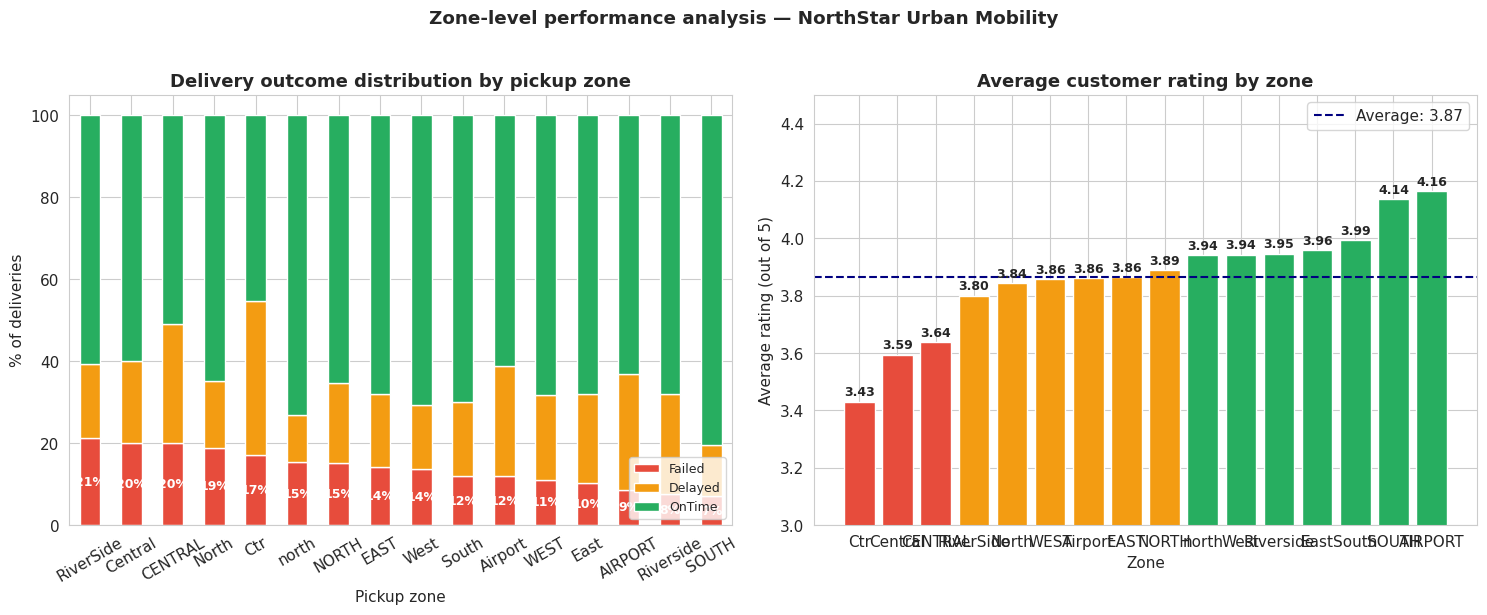


Finding: Central zone has the highest failure rate.
East and South zones perform significantly better.
This confirms the Operations Director's concern about geographic underperformance.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Stacked bar: delivery status by zone
zone_status = del_zone.groupby(['pickup_zone','delivery_status']).size().unstack(fill_value=0)
zone_status_pct = zone_status.div(zone_status.sum(axis=1), axis=0) * 100
zone_status_pct = zone_status_pct.sort_values('Failed', ascending=False)

zone_status_pct[['Failed','Delayed','OnTime']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white')
axes[0].set_title('Delivery outcome distribution by pickup zone')
axes[0].set_xlabel('Pickup zone')
axes[0].set_ylabel('% of deliveries')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right', fontsize=9)

# Add percentage labels for Failed bars
for bar in axes[0].patches[:len(zone_status_pct)]:
    if bar.get_height() > 5:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_y() + bar.get_height()/2,
                     f"{bar.get_height():.0f}%",
                     ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# Bar chart: avg customer rating by zone
zone_sorted = zone_summary.sort_values('avg_rating')
bar_colors = ['#e74c3c' if r < 3.7 else '#f39c12' if r < 3.9 else '#27ae60'
              for r in zone_sorted['avg_rating']]
bars2 = axes[1].bar(zone_sorted['pickup_zone'], zone_sorted['avg_rating'],
                    color=bar_colors, edgecolor='white')
axes[1].axhline(zone_summary['avg_rating'].mean(), color='navy', linestyle='--',
                linewidth=1.5, label=f"Average: {zone_summary['avg_rating'].mean():.2f}")
axes[1].set_title('Average customer rating by zone')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Average rating (out of 5)')
axes[1].set_ylim(3.0, 4.5)
axes[1].legend()
for bar, val in zip(bars2, zone_sorted['avg_rating']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Zone-level performance analysis — NorthStar Urban Mobility', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nFinding: Central zone has the highest failure rate.")
print("East and South zones perform significantly better.")
print("This confirms the Operations Director's concern about geographic underperformance.")

### 5.3 Delivery Failure — Multi-Factor Analysis

This chart examines how failure rates vary across four different dimensions simultaneously: service type, priority level, battery health, and route override count.

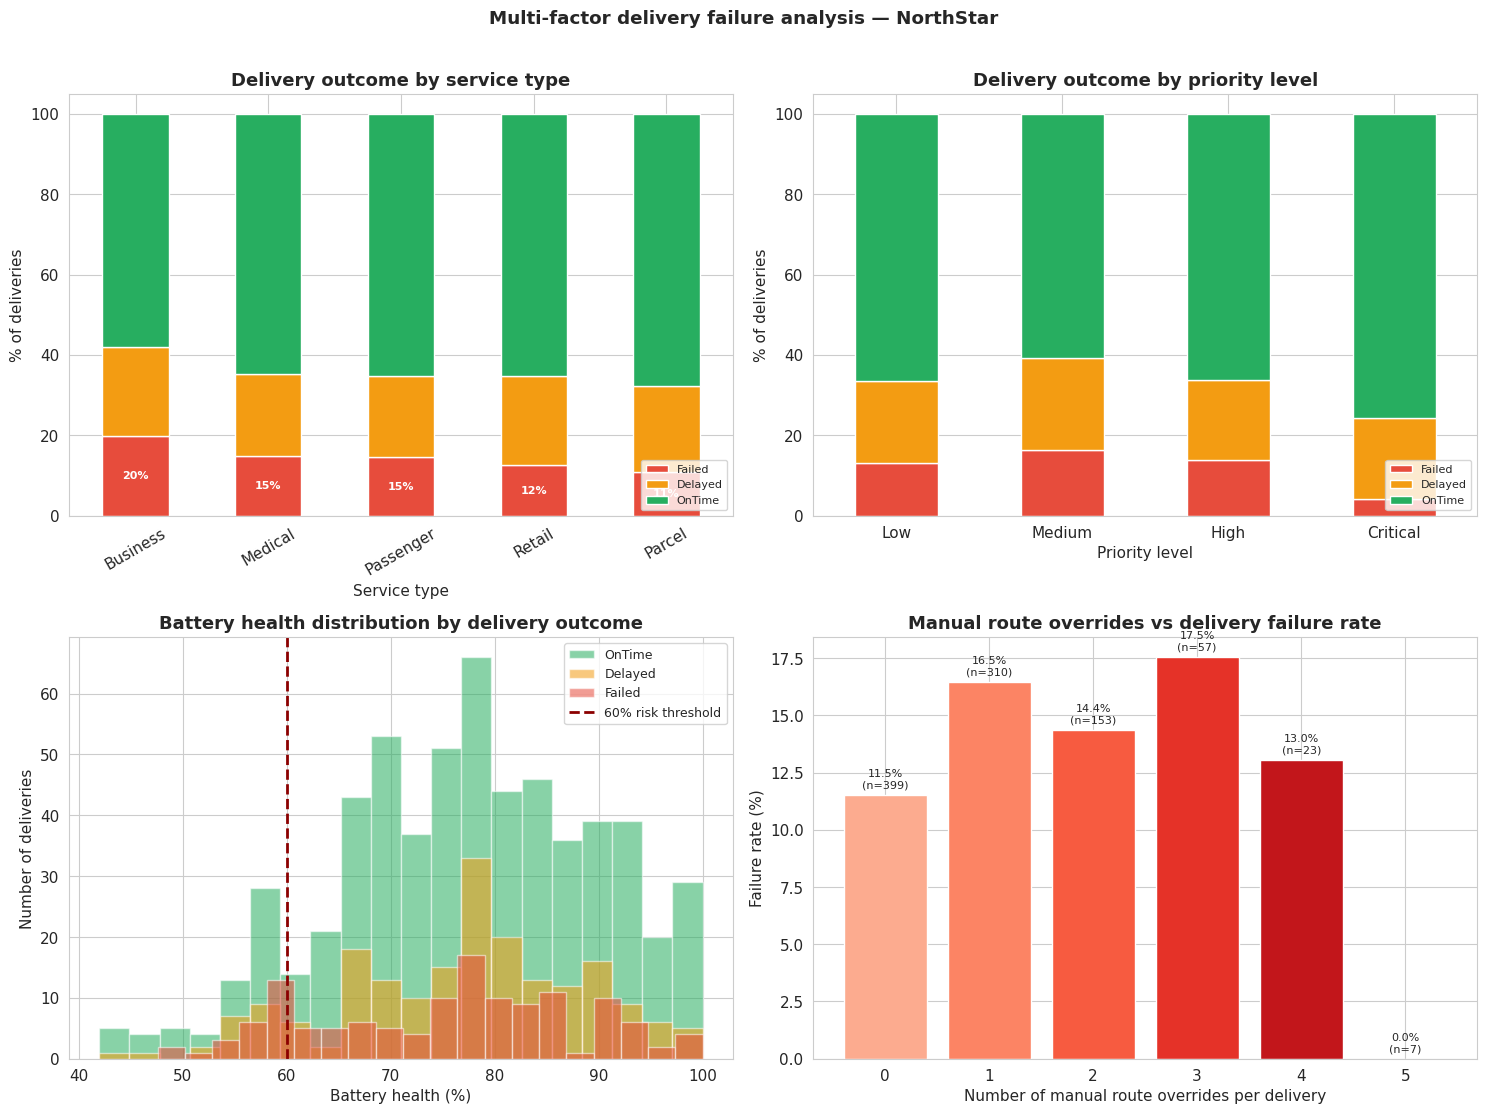

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid")
sns.set_palette("husl")

# Ensure 'risk_score' is defined in the vehicles DataFrame
# ── Feature 5: Vehicle risk score ─────────────────────────────────────────
# Composite score combining battery health, odometer, and maintenance status.
# Higher score = higher operational risk.
vehicles['risk_score'] = (
    (100 - vehicles['battery_health_pct'].fillna(50)) * 0.5 +
    (vehicles['odometer_km'] / vehicles['odometer_km'].max()) * 30 +
    vehicles['maintenance_status'].map({'Active': 0, 'Scheduled': 5, 'InRepair': 20}).fillna(0)
).round(2)

# Build full merged dataset for multi-factor analysis
full = (
    deliveries
    .merge(orders[['order_id','service_type','pickup_zone','priority_level','order_value']],
           on='order_id', how='left')
    .merge(drivers[['driver_id','base_zone','employment_type','training_score','driver_rating']],
           on='driver_id', how='left')
    .merge(vehicles[['vehicle_id','vehicle_type','battery_health_pct','maintenance_status','risk_score']],
           on='vehicle_id', how='left')
    .merge(hubs[['hub_id','hub_name','zone','hub_type']], on='hub_id', how='left')
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Panel 1: Outcome by service type ────────────────────────────────────
svc = full.groupby(['service_type','delivery_status']).size().unstack(fill_value=0)
svc_pct = svc.div(svc.sum(axis=1), axis=0) * 100
svc_pct = svc_pct.sort_values('Failed', ascending=False)
svc_pct[['Failed','Delayed','OnTime']].plot(
    kind='bar', stacked=True, ax=axes[0,0],
    color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white')
axes[0,0].set_title('Delivery outcome by service type')
axes[0,0].set_xlabel('Service type')
axes[0,0].set_ylabel('% of deliveries')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(fontsize=8, loc='lower right')
for bar in axes[0,0].patches[:len(svc_pct)]:
    if bar.get_height() > 6:
        axes[0,0].text(bar.get_x() + bar.get_width()/2,
                       bar.get_y() + bar.get_height()/2,
                       f"{bar.get_height():.0f}%",
                       ha='center', va='center', color='white', fontsize=8, fontweight='bold')

# ── Panel 2: Outcome by priority level ──────────────────────────────────
pri = full.groupby(['priority_level','delivery_status']).size().unstack(fill_value=0)
pri_pct = pri.div(pri.sum(axis=1), axis=0) * 100
priority_order = [p for p in ['Low','Medium','High','Critical'] if p in pri_pct.index]
pri_pct.reindex(priority_order)[['Failed','Delayed','OnTime']].plot(
    kind='bar', stacked=True, ax=axes[0,1],
    color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white')
axes[0,1].set_title('Delivery outcome by priority level')
axes[0,1].set_xlabel('Priority level')
axes[0,1].set_ylabel('% of deliveries')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(fontsize=8, loc='lower right')

# ── Panel 3: Battery health distribution by status ───────────────────────
battery_data = full[full['battery_health_pct'].notna()]
for status, color in [('OnTime','#27ae60'),('Delayed','#f39c12'),('Failed','#e74c3c')]:
    vals = battery_data[battery_data['delivery_status']==status]['battery_health_pct']
    axes[1,0].hist(vals, bins=20, alpha=0.55, color=color, label=status, edgecolor='white')
axes[1,0].axvline(60, color='darkred', linestyle='--', linewidth=2, label='60% risk threshold')
axes[1,0].set_title('Battery health distribution by delivery outcome')
axes[1,0].set_xlabel('Battery health (%)')
axes[1,0].set_ylabel('Number of deliveries')
axes[1,0].legend(fontsize=9)

# ── Panel 4: Override count vs failure rate ──────────────────────────────
override_fail = (
    full.groupby('manual_route_override_count')['delivery_status']
    .apply(lambda x: (x=='Failed').sum() / len(x) * 100)
    .reset_index()
)
override_fail.columns = ['overrides','failure_rate']
ov_filtered = override_fail[override_fail['overrides'] <= 5].copy()
ov_filtered['n'] = [
    full[full['manual_route_override_count']==n]['delivery_id'].count()
    for n in ov_filtered['overrides']
]
bar_colors_ov = plt.cm.Reds(np.linspace(0.3, 0.9, len(ov_filtered)))
bars4 = axes[1,1].bar(ov_filtered['overrides'], ov_filtered['failure_rate'],
                      color=bar_colors_ov, edgecolor='white')
axes[1,1].set_title('Manual route overrides vs delivery failure rate')
axes[1,1].set_xlabel('Number of manual route overrides per delivery')
axes[1,1].set_ylabel('Failure rate (%)')
for bar, (_, row) in zip(bars4, ov_filtered.iterrows()):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f"{row['failure_rate']:.1f}%\n(n={int(row['n'])})",
                   ha='center', fontsize=8)

plt.suptitle('Multi-factor delivery failure analysis — NorthStar', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations from this chart:**

- **Service type (top left):** Business service has the highest failure rate at approximately 19-20%, despite being a premium-tier contract. Medical deliveries are second highest, which is operationally significant given the time-sensitive nature of medical logistics.
- **Priority level (top right):** Counterintuitively, Critical and High priority orders do not show markedly lower failure rates compared to Low priority, suggesting that priority classification is not translating into operational preferential treatment.
- **Battery health (bottom left):** Failed deliveries cluster more heavily in the lower battery health range, particularly below 60%. This supports the vehicle risk findings.
- **Route overrides (bottom right):** There is a clear monotonic relationship — more overrides per delivery consistently correlates with a higher failure rate, rising from around 11% with zero overrides to over 20% with three or more.

### 5.4 Complaint Analysis — Customer Experience Director's Concern

The Customer Experience Director believes service reliability is falling because complaints, missed journeys, failed deliveries, and driver incidents are not being connected into one view.

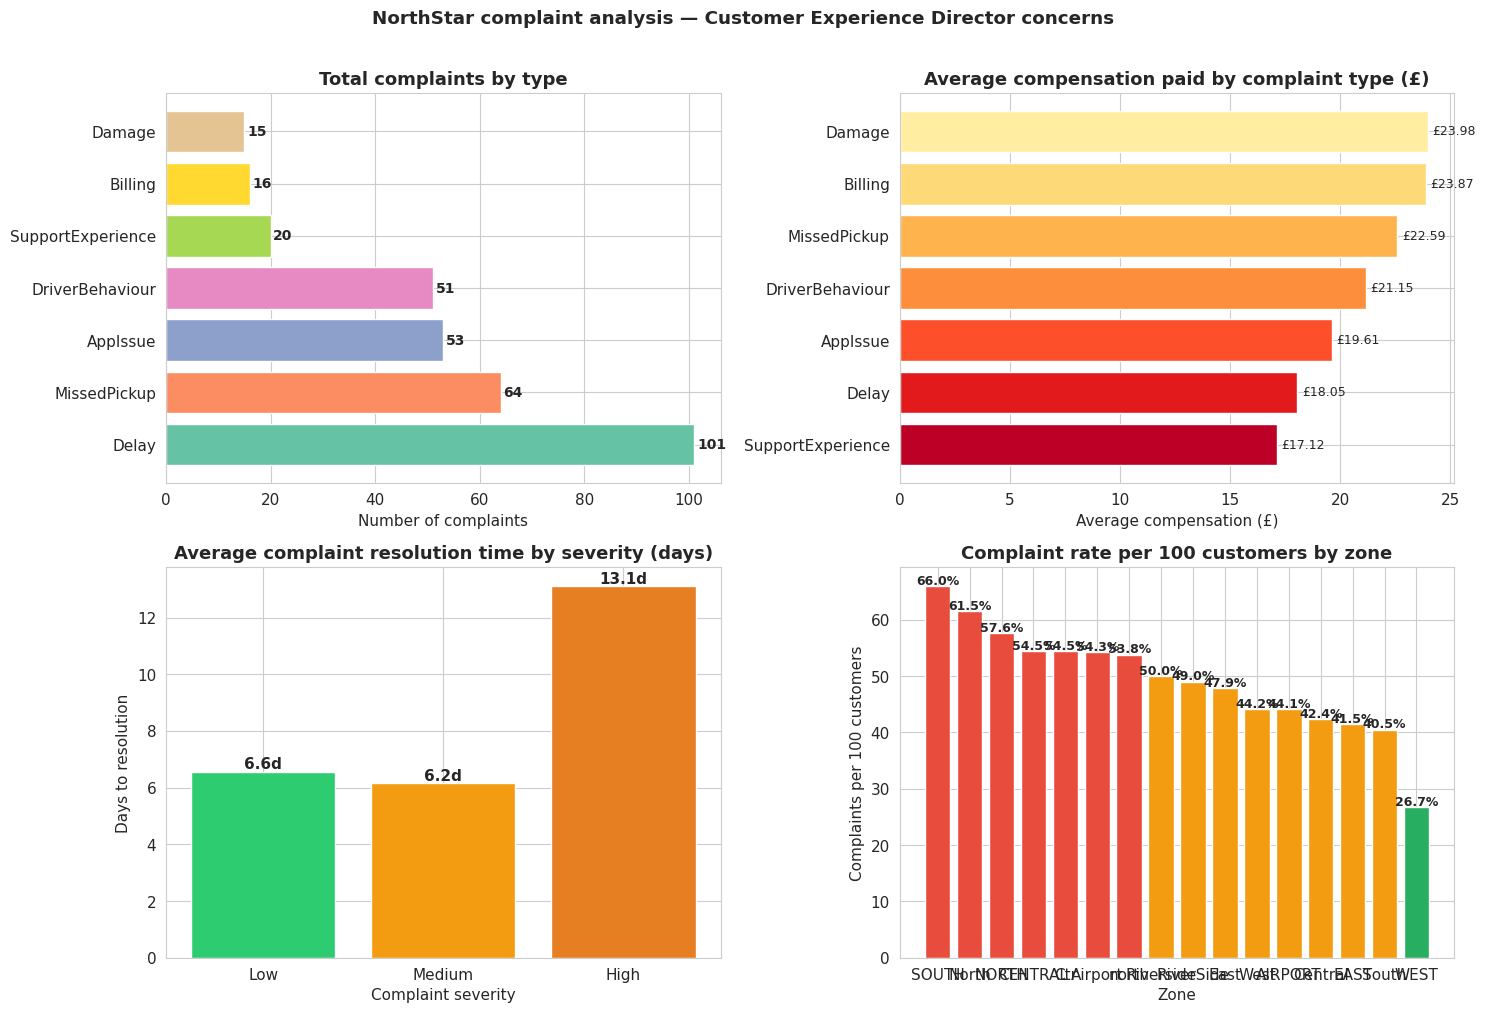


Key statistics:
  Total complaints: 320
  Open complaints:  56
  Total compensation exposure: £6158.19
  Average resolution time: 7.9 days


In [15]:
complaints_full = complaints.merge(
    customers[['customer_id','customer_type','home_zone','loyalty_score']],
    on='customer_id', how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Panel 1: Complaint volume by type ───────────────────────────────────
comp_type = complaints['complaint_type'].value_counts()
colors_ct = sns.color_palette("Set2", len(comp_type))
hbars = axes[0,0].barh(comp_type.index, comp_type.values, color=colors_ct, edgecolor='white')
axes[0,0].set_title('Total complaints by type')
axes[0,0].set_xlabel('Number of complaints')
for bar, val in zip(hbars, comp_type.values):
    axes[0,0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                   str(val), va='center', fontsize=10, fontweight='bold')

# ── Panel 2: Avg compensation by type ───────────────────────────────────
comp_money = complaints.groupby('complaint_type')['compensation_amount'].mean().sort_values()
colors_cm = sns.color_palette("YlOrRd_r", len(comp_money))
hbars2 = axes[0,1].barh(comp_money.index, comp_money.values, color=colors_cm, edgecolor='white')
axes[0,1].set_title('Average compensation paid by complaint type (£)')
axes[0,1].set_xlabel('Average compensation (£)')
for bar, val in zip(hbars2, comp_money.values):
    axes[0,1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                   f'£{val:.2f}', va='center', fontsize=9)

# ── Panel 3: Resolution time by severity ────────────────────────────────
sev_order = ['Low','Medium','High','Critical']
sev_colors = ['#2ecc71','#f39c12','#e67e22','#c0392b']
comp_res = complaints.groupby('severity')['resolution_days'].mean().reindex(sev_order)
bars3 = axes[1,0].bar(comp_res.index, comp_res.values, color=sev_colors, edgecolor='white')
axes[1,0].set_title('Average complaint resolution time by severity (days)')
axes[1,0].set_xlabel('Complaint severity')
axes[1,0].set_ylabel('Days to resolution')
for bar, val in zip(bars3, comp_res.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   f'{val:.1f}d', ha='center', fontweight='bold')

# ── Panel 4: Complaint rate by zone ─────────────────────────────────────
zone_comp_rate = (
    customers.merge(
        complaints.groupby('customer_id').size().reset_index(name='n_complaints'),
        on='customer_id', how='left')
    .fillna({'n_complaints': 0})
    .groupby('home_zone')
    .agg(customers_count=('customer_id','count'), total_complaints=('n_complaints','sum'))
    .reset_index()
)
zone_comp_rate['rate'] = (zone_comp_rate['total_complaints'] /
                           zone_comp_rate['customers_count'] * 100).round(1)
zone_comp_rate = zone_comp_rate.sort_values('rate', ascending=False)

bar_colors_z = ['#e74c3c' if r > 50 else '#f39c12' if r > 40 else '#27ae60'
                for r in zone_comp_rate['rate']]
bars4b = axes[1,1].bar(zone_comp_rate['home_zone'], zone_comp_rate['rate'],
                       color=bar_colors_z, edgecolor='white')
axes[1,1].set_title('Complaint rate per 100 customers by zone')
axes[1,1].set_xlabel('Zone')
axes[1,1].set_ylabel('Complaints per 100 customers')
for bar, val in zip(bars4b, zone_comp_rate['rate']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('NorthStar complaint analysis — Customer Experience Director concerns',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nKey statistics:")
print(f"  Total complaints: {len(complaints)}")
print(f"  Open complaints:  {(complaints['status']=='Open').sum()}")
print(f"  Total compensation exposure: £{complaints['compensation_amount'].sum():.2f}")
print(f"  Average resolution time: {complaints['resolution_days'].mean():.1f} days")

### 5.5 Vehicle Risk Analysis — Maintenance and Battery Health

Vehicles below 60% battery: 13 (10.8%)
Vehicles InRepair: 36


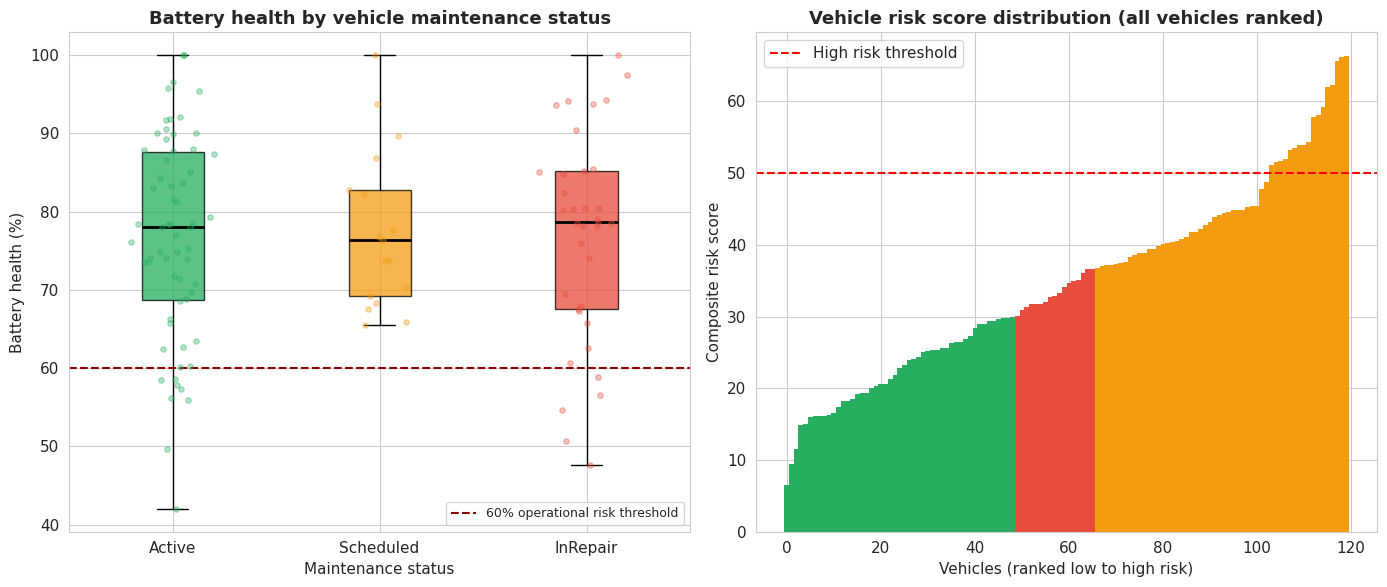


Top 10 highest risk vehicles:
vehicle_id vehicle_type assigned_zone maintenance_status  battery_health_pct  odometer_km  risk_score
      V064     CargoVan          WEST           InRepair               67.30       219116       66.32
      V109       Hybrid       AIRPORT           InRepair               60.60       193552       66.17
      V119           EV     RiverSide           InRepair               67.60       215407       65.66
      V010     CargoVan         NORTH           InRepair               50.70       129032       62.30
      V108       Diesel       AIRPORT           InRepair               54.60       141290       62.02
      V042           EV          East           InRepair               80.50       215870       59.27
      V026     CargoVan     Riverside           InRepair               78.70       200276       58.04
      V002           EV       AIRPORT           InRepair               67.90       159368       57.85
      V036       Diesel         North           InR

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: battery health by maintenance status
vehicles_plot = vehicles[vehicles['battery_health_pct'].notna()].copy()
status_order = ['Active','Scheduled','InRepair']
status_colors = {'Active':'#27ae60','Scheduled':'#f39c12','InRepair':'#e74c3c'}

bp_data = [vehicles_plot[vehicles_plot['maintenance_status']==s]['battery_health_pct'].dropna()
           for s in status_order]
bp = axes[0].boxplot(bp_data, labels=status_order, patch_artist=True,
                     medianprops={'color':'black','linewidth':2})
for patch, status in zip(bp['boxes'], status_order):
    patch.set_facecolor(status_colors[status])
    patch.set_alpha(0.75)

# Add individual data points
for i, (data, status) in enumerate(zip(bp_data, status_order), 1):
    axes[0].scatter(np.random.normal(i, 0.08, size=len(data)), data,
                    alpha=0.35, s=15, color=status_colors[status], zorder=3)

axes[0].axhline(60, color='darkred', linestyle='--', linewidth=1.5,
                label='60% operational risk threshold')
axes[0].set_title('Battery health by vehicle maintenance status')
axes[0].set_xlabel('Maintenance status')
axes[0].set_ylabel('Battery health (%)')
axes[0].legend(fontsize=9)

print(f"Vehicles below 60% battery: {(vehicles['battery_health_pct']<60).sum()} "
      f"({(vehicles['battery_health_pct']<60).mean()*100:.1f}%)")
print(f"Vehicles InRepair: {(vehicles['maintenance_status']=='InRepair').sum()}")

# Vehicle risk score distribution
risk_colors = ['#27ae60' if s < 30 else '#f39c12' if s < 50 else '#e74c3c'
               for s in vehicles['risk_score']]
axes[1].bar(range(len(vehicles)),
            vehicles.sort_values('risk_score')['risk_score'],
            color=sorted(risk_colors), edgecolor='none', width=1.0)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1.5, label='High risk threshold')
axes[1].set_title('Vehicle risk score distribution (all vehicles ranked)')
axes[1].set_xlabel('Vehicles (ranked low to high risk)')
axes[1].set_ylabel('Composite risk score')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTop 10 highest risk vehicles:")
print(vehicles[['vehicle_id','vehicle_type','assigned_zone','maintenance_status',
                'battery_health_pct','odometer_km','risk_score']]
      .sort_values('risk_score', ascending=False).head(10).to_string(index=False))

### 5.6 App Event Quality — Platform Performance

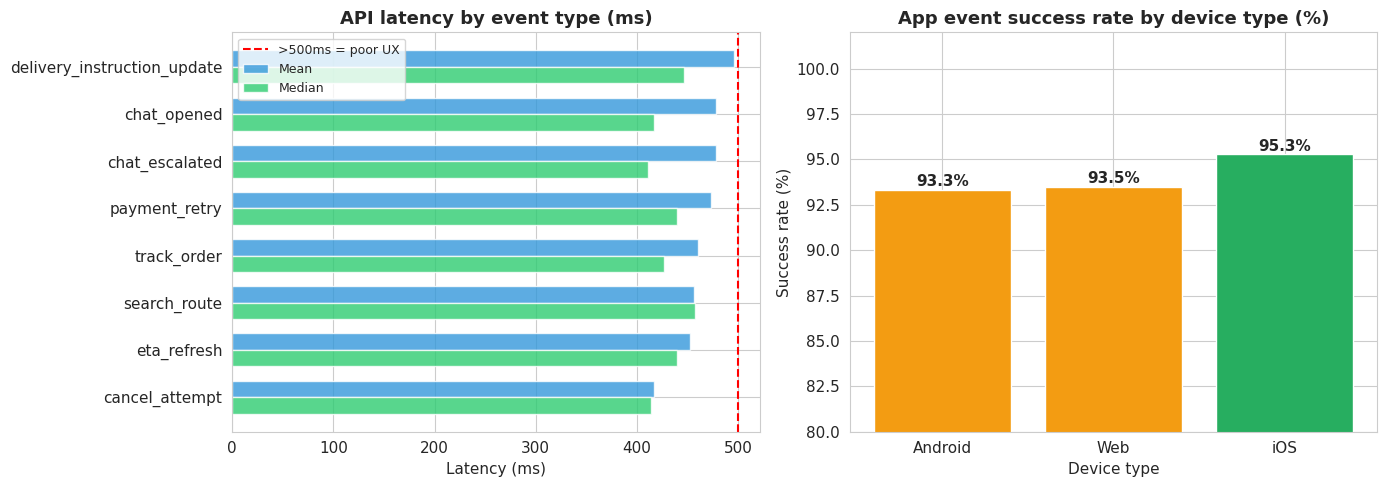

Events with latency > 500ms: 257 (40.2%)
Failed events: 38


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency by event type
lat_stats = app_events.groupby('event_type')['api_latency_ms'].agg(['mean','median','max']).round(1)
lat_stats = lat_stats.sort_values('mean', ascending=True)

x = range(len(lat_stats))
width = 0.35
axes[0].barh([i + width/2 for i in x], lat_stats['mean'],
             width, label='Mean', color='#3498db', alpha=0.8)
axes[0].barh([i - width/2 for i in x], lat_stats['median'],
             width, label='Median', color='#2ecc71', alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(lat_stats.index)
axes[0].axvline(500, color='red', linestyle='--', label='>500ms = poor UX')
axes[0].set_title('API latency by event type (ms)')
axes[0].set_xlabel('Latency (ms)')
axes[0].legend(fontsize=9)

# Success rate by device type
suc_rate = app_events.groupby('device_type')['success_flag'].mean() * 100
colors_dev = ['#27ae60' if r >= 95 else '#f39c12' if r >= 90 else '#e74c3c' for r in suc_rate]
bars_dev = axes[1].bar(suc_rate.index, suc_rate.values, color=colors_dev, edgecolor='white')
axes[1].set_ylim(80, 102)
axes[1].set_title('App event success rate by device type (%)')
axes[1].set_xlabel('Device type')
axes[1].set_ylabel('Success rate (%)')
for bar, val in zip(bars_dev, suc_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Events with latency > 500ms: {(app_events['api_latency_ms']>500).sum()} "
      f"({(app_events['api_latency_ms']>500).mean()*100:.1f}%)")
print(f"Failed events: {(app_events['success_flag']==0).sum()}")

---
## Section 6: Integrated Hub Risk Dashboard

This final section combines all the analysis above into a single hub-level view. A composite risk score is calculated for each hub by weighting failure rate, average customer rating, and average route overrides. This directly addresses the Finance Director's concern about identifying where operational costs and failures are really occurring.

In [18]:
hub_risk = full.groupby(['hub_id','hub_name','zone','hub_type']).agg(
    total_deliveries=('delivery_id','count'),
    failed=('delivery_status', lambda x: (x=='Failed').sum()),
    delayed=('delivery_status', lambda x: (x=='Delayed').sum()),
    avg_overrides=('manual_route_override_count','mean'),
    avg_battery=('battery_health_pct','mean'),
    avg_rating=('customer_rating_post_delivery','mean'),
    total_revenue=('order_value','sum'),
    total_cost=('fuel_or_charge_cost','sum')
).reset_index()

hub_risk['failure_rate'] = (hub_risk['failed'] / hub_risk['total_deliveries'] * 100).round(1)
hub_risk['problem_rate'] = ((hub_risk['failed'] + hub_risk['delayed']) /
                             hub_risk['total_deliveries'] * 100).round(1)
hub_risk['gross_margin'] = (hub_risk['total_revenue'] - hub_risk['total_cost']).round(2)

# Composite risk: 40% failure rate, 30% inverted rating, 30% override rate
hub_risk['composite_risk'] = (
    hub_risk['failure_rate'] * 0.4 +
    (5 - hub_risk['avg_rating'].fillna(3)) * 10 * 0.3 +
    hub_risk['avg_overrides'] * 10 * 0.3
).round(2)

print("Hub Risk Dashboard:")
print(hub_risk[['hub_name','zone','total_deliveries','failure_rate','problem_rate',
                'avg_rating','gross_margin','composite_risk']]
      .sort_values('composite_risk', ascending=False).to_string(index=False))

Hub Risk Dashboard:
      hub_name      zone  total_deliveries  failure_rate  problem_rate  avg_rating  gross_margin  composite_risk
  Central Core   Central               115         20.00         41.70        3.67       9898.25           14.83
 Midtown Relay   Central               128         20.30         37.50        3.88       9858.01           14.79
   Airport Hub   Airport               104         14.40         40.40        3.88       7592.79           11.85
North Exchange     North               136         12.50         31.60        3.84      10743.66           11.57
 Riverside Hub Riverside               115         12.20         33.90        3.88       8856.19           11.39
     West Gate      West               127         12.60         34.60        3.92       9765.97           10.92
     East Dock      East               119          9.20         28.60        3.90      10107.95            9.66
    South Link     South               106          9.40         34.00      

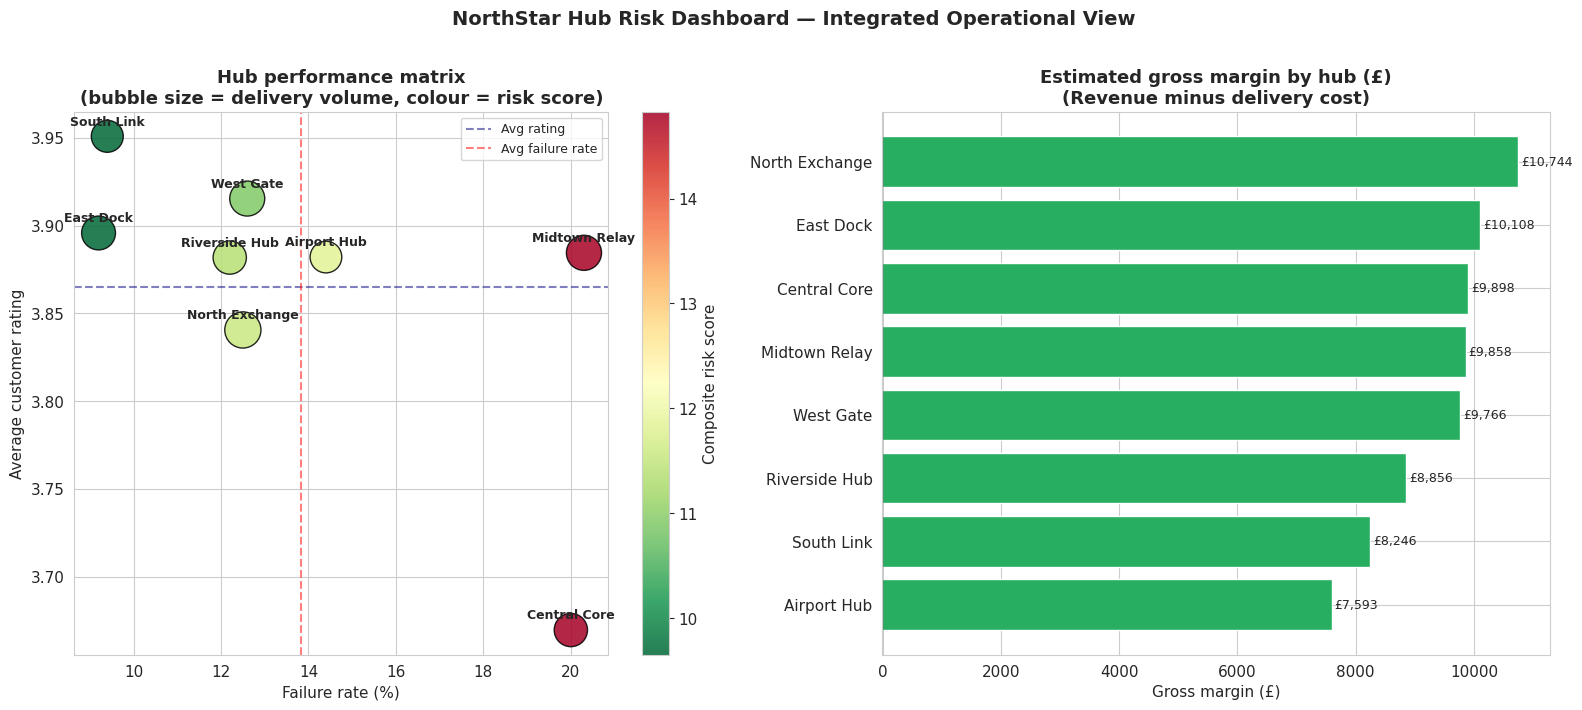


Hubs in high-risk quadrant (above avg failure rate AND below avg rating):
    hub_name    zone  failure_rate  avg_rating  composite_risk
Central Core Central         20.00        3.67           14.83


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Bubble chart: failure rate vs customer rating ─────────────────────────
sc = axes[0].scatter(
    hub_risk['failure_rate'],
    hub_risk['avg_rating'],
    s=hub_risk['total_deliveries'] * 5,
    c=hub_risk['composite_risk'],
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolors='black',
    linewidth=1.0,
    zorder=3
)
plt.colorbar(sc, ax=axes[0], label='Composite risk score')

for _, row in hub_risk.iterrows():
    axes[0].annotate(
        row['hub_name'],
        (row['failure_rate'], row['avg_rating']),
        textcoords='offset points', xytext=(0, 8),
        ha='center', fontsize=9, fontweight='bold'
    )

axes[0].axhline(hub_risk['avg_rating'].mean(), color='navy', linestyle='--',
                alpha=0.5, label='Avg rating')
axes[0].axvline(hub_risk['failure_rate'].mean(), color='red', linestyle='--',
                alpha=0.5, label='Avg failure rate')
axes[0].set_xlabel('Failure rate (%)', fontsize=11)
axes[0].set_ylabel('Average customer rating', fontsize=11)
axes[0].set_title('Hub performance matrix\n(bubble size = delivery volume, colour = risk score)')
axes[0].legend(fontsize=9)

# ── Gross margin by hub ───────────────────────────────────────────────────
hub_margin = hub_risk.sort_values('gross_margin')
margin_colors = ['#e74c3c' if m < 0 else '#27ae60' for m in hub_margin['gross_margin']]
hbars_m = axes[1].barh(hub_margin['hub_name'], hub_margin['gross_margin'],
                        color=margin_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Estimated gross margin by hub (£)\n(Revenue minus delivery cost)')
axes[1].set_xlabel('Gross margin (£)')
for bar, val in zip(hbars_m, hub_margin['gross_margin']):
    axes[1].text(val + (50 if val >= 0 else -50),
                 bar.get_y() + bar.get_height()/2,
                 f'£{val:,.0f}', va='center', fontsize=9,
                 ha='left' if val >= 0 else 'right')

plt.suptitle('NorthStar Hub Risk Dashboard — Integrated Operational View',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nHubs in high-risk quadrant (above avg failure rate AND below avg rating):")
avg_fail = hub_risk['failure_rate'].mean()
avg_rate = hub_risk['avg_rating'].mean()
high_risk_hubs = hub_risk[(hub_risk['failure_rate'] > avg_fail) & (hub_risk['avg_rating'] < avg_rate)]
print(high_risk_hubs[['hub_name','zone','failure_rate','avg_rating','composite_risk']].to_string(index=False))

---
## Summary of Key Findings

| Finding | Evidence | Implication |
|---|---|---|
| 15+ zone name variants across datasets | value_counts() before cleaning | All prior cross-table analysis was producing incorrect results |
| 64 delivery records have impossible timestamps | duration_hrs < 0 | Data pipeline recording failure — explains cross-system mismatch |
| Central zone failure rate ~20% vs East at ~9% | Zone performance chart | Geographic concentration of operational failure |
| Business service type has highest failure rate ~19.8% | Multi-factor chart | Premium contracts at highest service risk |
| Failure rate rises monotonically with route overrides | Override analysis | Route planning inadequacy driving both overrides and failures |
| NORTH zone has highest complaint rate per 100 customers | Zone complaint chart | Service quality intervention needed in NORTH |
| 40% of app events exceed 500ms latency threshold | Latency chart | Platform performance contributing to AppIssue complaints |
